In [12]:
import pandas as pd

df = pd.read_csv("../data/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
print(df.shape)

print(df.columns)

df.info()

(10000, 14)
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  100

In [14]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [15]:
df["Exited"].value_counts(normalize=True) * 100


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

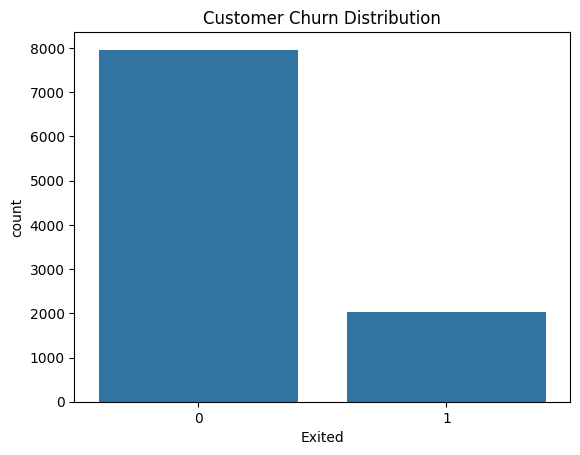

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution")

plt.show()

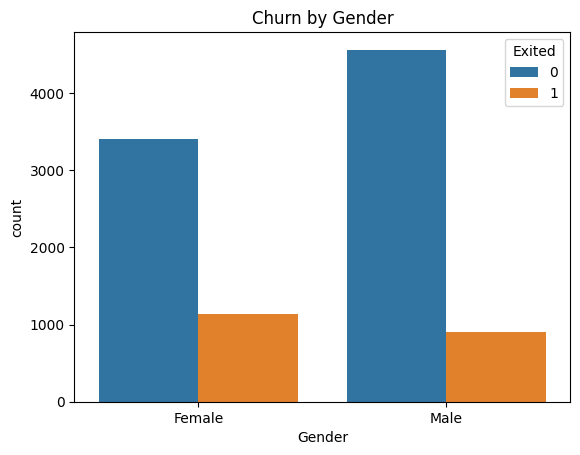

In [19]:
sns.countplot(x="Gender", hue="Exited", data=df)

plt.title("Churn by Gender")

plt.show()

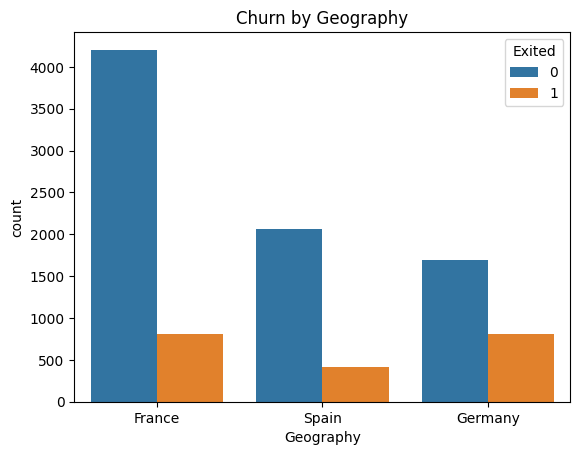

In [21]:
sns.countplot(x="Geography", hue="Exited", data=df)

plt.title("Churn by Geography")

plt.show()

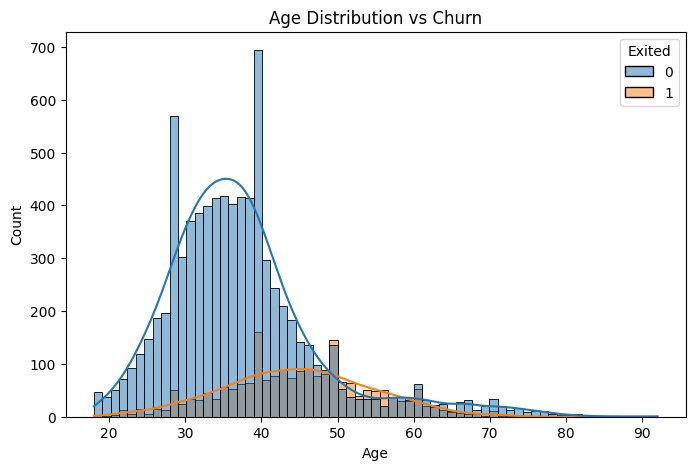

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", hue="Exited", kde=True)

plt.title("Age Distribution vs Churn")

plt.show()

In [26]:
# Remove unnecessary columns

df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

df.head()

KeyError: "['RowNumber', 'CustomerId', 'Surname'] not found in axis"

In [28]:
# Convert categorical columns into numbers

df = pd.get_dummies(df, drop_first=True)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [30]:
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df.drop("Exited", axis=1)
y = df["Exited"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
model = LogisticRegression(max_iter=5000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Report
print(classification_report(y_test, y_pred))


Accuracy: 0.81
[[1538   69]
 [ 311   82]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.54      0.21      0.30       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.60      2000
weighted avg       0.78      0.81      0.77      2000



d:\Hackathon_project\Bank-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
import joblib

joblib.dump(model, "../models/churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!
